In [1]:
import numpy as np
from gfapy import Gfa
import networkx as nx

In [2]:
gfa = Gfa("H	VN:Z:1.0\n\
S	u0	TAAC	LN:i:4	SC:f:1.0\n\
S	u1	CCCG	LN:i:4	SC:f:1.0\n\
L	u0	+	u1	+	0M	EC:i:1\n\
L	u1	-	u0	-	0M	EC:i:1")

In [3]:
gfa.segments

[gfapy.Line('S	u0	TAAC	LN:i:4	SC:f:1.0',version='gfa1',vlevel=1),
 gfapy.Line('S	u1	CCCG	LN:i:4	SC:f:1.0',version='gfa1',vlevel=1)]

In [4]:
n = 2
K = 2
T = 2

In [5]:
graph = nx.Graph()

for segment_line in gfa.segments:
    graph.add_node(segment_line.name, weight=segment_line.SC)

graph.add_node('end')

for segment_line in gfa.segments:
    graph.add_edges_from([(segment_line.name, 'end')])
for edge_line in gfa.edges:
    graph.add_edges_from([
        (edge_line.sid1.name, edge_line.sid2.name),
    ])

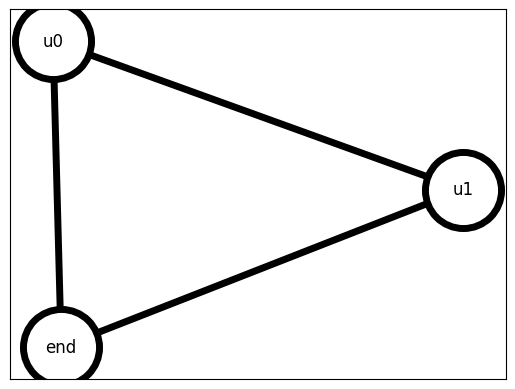

In [6]:
options = {
    "font_size": 12,
    "node_size": 3000,
    "node_color": "white",
    "edgecolors": "black",
    "linewidths": 5,
    "width": 5,
}
nx.draw_networkx(graph, nx.spring_layout(graph), **options)


In [20]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.circuit import Parameter

In [33]:
ceil_log_n2 = int(np.ceil(np.log2(n+2)))

In [9]:
def is_equal_to(num_qubits: int, value):
    circ = QuantumCircuit(num_qubits + 1)
    bin_value = [int(x) for x in np.binary_repr(value, num_qubits)]
    for idx, b in enumerate(bin_value):
        if b == 0:
            circ.x(idx)
    
    circ.mcx(list(range(num_qubits)), num_qubits)
    for idx, b in enumerate(bin_value):
        if b == 0:
            circ.x(idx)
    return circ

In [ ]:
is_equal_circ = is_equal_to(ceil_log_n2, 1)
is_equal_circ.draw()

┌───┐     ┌───┐
q_0: ┤ X ├──■──┤ X ├
     └───┘  │  └───┘
q_1: ───────■───────
          ┌─┴─┐     
q_2: ─────┤ X ├─────
          └───┘

In [11]:
def controlled_copy(num_qubits, K):
    circ = QuantumCircuit((K+1) * num_qubits + 1 + 1)
    # C_copy_Flag, To be copied, list(reg_to_be_copied_into, spare_registers), swap_spare_registers_flag
    circ.x((K+1) * num_qubits + 1)

    for i in range(num_qubits+1, 2*num_qubits+1):
        circ.x(i)
    circ.mcx(list(range(num_qubits+1, 2*num_qubits+1)), (K+1) * num_qubits + 1)

    for i in range(num_qubits+1, 2*num_qubits+1):
        circ.x(i)
    for i in range(num_qubits):
        top = K * num_qubits + i + 1
        for idx in range(top, 1+num_qubits+i, -1):
            circ.cswap((K+1) * num_qubits + 1, idx, idx-1)
            
    circ.x((K+1) * num_qubits + 1)
    for i in range(num_qubits+1, 2*num_qubits+1):
        circ.x(i)
    circ.mcx(list(range(num_qubits+1, 2*num_qubits+1)), (K+1) * num_qubits + 1)
    for i in range(num_qubits+1, 2*num_qubits+1):
        circ.x(i)

    for i in range(num_qubits):
        circ.mcx([0, i + 1], num_qubits + i + 1)
    return circ

In [12]:
cc_circ = controlled_copy(2, 3)
cc_circ.draw()

q_0: ───────────────────────────────────────────────────────■────■──
                                                            │    │  
q_1: ───────────────────────────────────────────────────────■────┼──
                                                            │    │  
q_2: ───────────────────────────────────────────────────────┼────■──
     ┌───┐     ┌───┐         ┌───┐                   ┌───┐┌─┴─┐  │  
q_3: ┤ X ├──■──┤ X ├───────X─┤ X ├────────────────■──┤ X ├┤ X ├──┼──
     ├───┤  │  ├───┤       │ └───┘         ┌───┐  │  ├───┤└───┘┌─┴─┐
q_4: ┤ X ├──■──┤ X ├────X──X─────────────X─┤ X ├──■──┤ X ├─────┤ X ├
     └───┘  │  └───┘    │  │             │ └───┘  │  └───┘     └───┘
q_5: ───────┼────────X──X──┼──────────X──X────────┼─────────────────
            │        │  │  │          │  │        │                 
q_6: ───────┼────X───X──┼──┼───────X──X──┼────────┼─────────────────
            │    │   │  │  │       │  │  │        │                 
q_7: ───────┼────X───┼──┼──┼───X───X──┼──┼────────┼─────────────────
            │    │   │  │  │   │   │  │  │        │                 
q_8: ───────┼────┼───┼──┼──┼───X───┼──┼──┼────────┼─────────────────
     ┌───┐┌─┴─┐  │   │  │  │   │   │  │  │ ┌───┐┌─┴─┐               
q_9: ┤ X ├┤ X ├──■───■──■──■───■───■──■──■─┤ X ├┤ X ├───────────────
     └───┘└───┘                            └───┘└───┘

In [29]:
def compute_next_nodes(circuit: QuantumCircuit, registers):
    cc_circ = controlled_copy(ceil_log_n2, K)
    for t in range(T-1):
        for j in range(1, n+2):
            is_equal_circ = is_equal_to(ceil_log_n2, j)
            
            circuit.barrier(label=f'is_equal c_{t}, {j}')
            circuit.compose(
                is_equal_circ, 
                list(range(circuit.find_bit(registers[f'solution_{t}'][0]).index, circuit.find_bit(registers[f'solution_{t}'][-1]).index + 1)) \
                    + [circuit.find_bit(registers[f'is_equal_flag_{t}'][0]).index],
                inplace=True
            )

            circuit.barrier(label=f'c_copy c_{t+1} -> next node list')
            is_equal_flag = circuit.find_bit(registers[f'is_equal_flag_{t}'][0]).index
            to_copy = list(range(
                circuit.find_bit(registers[f'solution_{t+1}'][0]).index, circuit.find_bit(registers[f'solution_{t+1}'][-1]).index + 1
            ))
            copy_registers = list(range(
                circuit.find_bit(registers[f'next_node_{j}_0'][0]).index, circuit.find_bit(registers[f'next_node_{j}_{K-1}'][-1]).index + 1
            ))
            next_node_flag = circuit.find_bit(registers[f'next_node_flag_{j}'][0]).index

            circuit.compose(
                cc_circ, 
                [is_equal_flag] + to_copy + copy_registers + [next_node_flag],
                inplace=True
            )

            circuit.barrier(label=f'uncompute is_equal c_{t}, {j}')
            circuit.compose(
                is_equal_circ, 
                list(range(circuit.find_bit(registers[f'solution_{t}'][0]).index, circuit.find_bit(registers[f'solution_{t}'][-1]).index + 1)) \
                    + [circuit.find_bit(registers[f'is_equal_flag_{t}'][0]).index],
                inplace=True
            )
            circuit.barrier()
    return circuit

In [30]:
def penalise_graph_steps(circuit, registers):
    theta = Parameter('theta')
    nodes = list(graph.nodes)
    for i in range(1, n+1):
        for j in range(1, n+1):
            if (nodes[i-1], nodes[j-1]) not in graph.edges:
                is_equal_circ = is_equal_to(ceil_log_n2, j)
                circuit.barrier(label=f'penalty for {nodes[i-1], nodes[j-1]}')
                for k in range(K):
                    circuit.compose(
                        is_equal_circ,
                        list(range(
                            circuit.find_bit(registers[f'next_node_{j}_{k}'][0]).index, circuit.find_bit(registers[f'next_node_{j}_{k}'][-1]).index + 1
                        )) + [circuit.find_bit(registers[f'constraint_rotate_flag_{j}_{k}'][0]).index],
                        inplace=True
                    )
                    circuit.rz(
                        theta, 
                        circuit.find_bit(registers[f'constraint_rotate_flag_{j}_{k}'][0]).index
                    )
                    circuit.compose(
                        is_equal_circ,
                        list(range(
                            circuit.find_bit(registers[f'next_node_{j}_{k}'][0]).index, circuit.find_bit(registers[f'next_node_{j}_{k}'][-1]).index + 1
                        )) + [circuit.find_bit(registers[f'constraint_rotate_flag_{j}_{k}'][0]).index],
                        inplace=True
                    )
            circuit.barrier()
            
    for j in range(1, n+1):
        is_equal_circ = is_equal_to(ceil_log_n2, j)
        circuit.barrier(label=f'penalty for {nodes[-1], nodes[j-1]}')
        for k in range(K):
            circuit.compose(
                is_equal_circ,
                list(range(
                    circuit.find_bit(registers[f'next_node_{j}_{k}'][0]).index, circuit.find_bit(registers[f'next_node_{j}_{k}'][-1]).index + 1
                )) + [circuit.find_bit(registers[f'constraint_rotate_flag_{j}_{k}'][0]).index],
                inplace=True
            )
            circuit.rz(
                theta, 
                circuit.find_bit(registers[f'constraint_rotate_flag_{j}_{k}'][0]).index
            )
            circuit.compose(
                is_equal_circ,
                list(range(
                    circuit.find_bit(registers[f'next_node_{j}_{k}'][0]).index, circuit.find_bit(registers[f'next_node_{j}_{k}'][-1]).index + 1
                )) + [circuit.find_bit(registers[f'constraint_rotate_flag_{j}_{k}'][0]).index],
                inplace=True
            )

    return circuit

In [31]:
def get_constraint_circuit(state_prep_circuit: QuantumCircuit | None = None):
    circuit = QuantumCircuit()


    registers = {f'solution_{t}' : QuantumRegister(ceil_log_n2, name=f'solution_{t}') for t in range(T)}
    registers.update({f'is_equal_flag_{t}': QuantumRegister(1, name=f'is_equal_flag_{t}') for t in range(T-1)})
    registers.update({f'next_node_{j}_{k}': QuantumRegister(ceil_log_n2, name=f'next_node_{j}_{k}') for j in range(1, n+2) for k in range(K)})
    registers.update({f'next_node_flag_{j}': QuantumRegister(1, name=f'next_node_flag_{j}') for j in range(1, n+2)})
    registers.update({f'constraint_rotate_flag_{j}_{k}': QuantumRegister(1, name=f'constraint_rotate_flag_{j}_{k}') for j in range(1, n+2) for k in range(K)})
    registers.update({f'count_{j}': QuantumRegister(np.ceil(np.log2(K+1)), name=f'count_{j}') for j in range(1, n+1)})
    registers.update({f'count_rotate_flag_{j}': QuantumRegister(1, name=f'count_rotate_flag_{j}') for j in range(1, n+1)})

    for register in registers.values():
        circuit.add_register(register)


    if state_prep_circuit is not None:
        circuit.compose(state_prep_circuit, list(range(T * ceil_log_n2)), inplace=True)

    circuit = compute_next_nodes(circuit, registers)
    circuit = penalise_graph_steps(circuit, registers)
    circuit = compute_next_nodes(circuit, registers)
            
    return circuit

In [34]:
state_prep = QuantumCircuit(T * ceil_log_n2)
state_prep.x(0)
state_prep.h(1)
state_prep.x(2)
state_prep.h(3)
circuit = get_constraint_circuit(state_prep)
circuit.save_statevector()
circuit.measure_all()

In [35]:
circuit.num_qubits

32

In [36]:
circuit.draw()

┌───┐ is_equal c_0, 1 ┌───┐     ┌───┐»
              solution_0_0: ┤ X ├────────░────────┤ X ├──■──┤ X ├»
                            ├───┤        ░        └───┘  │  └───┘»
              solution_0_1: ┤ H ├────────░───────────────■───────»
                            ├───┤        ░               │       »
              solution_1_0: ┤ X ├────────░───────────────┼───────»
                            ├───┤        ░               │       »
              solution_1_1: ┤ H ├────────░───────────────┼───────»
                            └───┘        ░             ┌─┴─┐     »
           is_equal_flag_0: ─────────────░─────────────┤ X ├─────»
                                         ░             └───┘     »
           next_node_1_0_0: ─────────────░───────────────────────»
                                         ░                       »
           next_node_1_0_1: ─────────────░───────────────────────»
                                         ░                       »
           next_node_1_1_0: ─────────────░───────────────────────»
                                         ░                       »
           next_node_1_1_1: ─────────────░───────────────────────»
                                         ░                       »
           next_node_2_0_0: ─────────────░───────────────────────»
                                         ░                       »
           next_node_2_0_1: ─────────────░───────────────────────»
                                         ░                       »
           next_node_2_1_0: ─────────────░───────────────────────»
                                         ░                       »
           next_node_2_1_1: ─────────────░───────────────────────»
                                         ░                       »
           next_node_3_0_0: ─────────────░───────────────────────»
                                         ░                       »
           next_node_3_0_1: ─────────────░───────────────────────»
                                         ░                       »
           next_node_3_1_0: ─────────────░───────────────────────»
                                         ░                       »
           next_node_3_1_1: ─────────────░───────────────────────»
                                         ░                       »
          next_node_flag_1: ─────────────░───────────────────────»
                                         ░                       »
          next_node_flag_2: ─────────────░───────────────────────»
                                         ░                       »
          next_node_flag_3: ─────────────░───────────────────────»
                                         ░                       »
constraint_rotate_flag_1_0: ─────────────░───────────────────────»
                                         ░                       »
constraint_rotate_flag_1_1: ─────────────░───────────────────────»
                                         ░                       »
constraint_rotate_flag_2_0: ─────────────░───────────────────────»
                                         ░                       »
constraint_rotate_flag_2_1: ─────────────░───────────────────────»
                                         ░                       »
constraint_rotate_flag_3_0: ─────────────░───────────────────────»
                                         ░                       »
constraint_rotate_flag_3_1: ─────────────░───────────────────────»
                                         ░                       »
                 count_1_0: ─────────────░───────────────────────»
                                         ░                       »
                 count_1_1: ─────────────░───────────────────────»
                                         ░                       »
                 count_2_0: ─────────────░───────────────────────»
                                         ░                       »
                 count_2_1: ─────────────░───────────────────────»
        

In [22]:
sim = AerSimulator()

In [23]:
run_job = sim.run(circuit.assign_parameters({p: np.pi/4 for p in circuit.parameters}))
result = run_job.result()

KeyboardInterrupt: 

In [ ]:
sv = result.get_statevector()
data = np.array(sv.data)

In [ ]:
data[np.nonzero(data)]